# PA Renal Analysis
- Analysis of PA renal cohort (non-transplanted and post-transplant)
- Dependent: Protein creatinine ratio, Albumin excretion 24h, Protein excretion 24h, Proteinuria_spot (qualitative present/absent), Proteinuria_24h (qualitative present/absent), Creatinine, Cystatin_C, eGFR_sCr, eGFR_Cystatin, CKD (qualitative, present/absent, which means GFR less than 60 based on Cystatin C)

In [3]:
import math
import subprocess
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn is available even in a fresh environment
try:
    import seaborn as sns
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])
    import seaborn as sns

try:
    import plotly.express as px
    import plotly.graph_objects as go
    import plotly.io as pio
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly"])
    import plotly.express as px
    import plotly.graph_objects as go
    import plotly.io as pio

data_pa_non = pd.read_csv('Pa_renal_nontransplanted.csv')
data_pa_post = pd.read_csv('pa_renal_post-transplanted.csv')

# Combine datasets for analysis
data_all = pd.concat([data_pa_non, data_pa_post], ignore_index=True)

print(f"Non-transplanted: {len(data_pa_non)} samples")
print(f"Post-transplant: {len(data_pa_post)} samples")
print(f"Total: {len(data_all)} samples")

# Clean data: replace spaces with NaN and convert to numeric
def clean_dataframe(df):
    df_clean = df.copy()
    # Replace spaces and empty strings with NaN
    df_clean = df_clean.replace(r'^\s*$', np.nan, regex=True)
    # Convert all columns to numeric where possible
    for col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='ignore')
    return df_clean

data_all = clean_dataframe(data_all)
data_pa_non = clean_dataframe(data_pa_non)
data_pa_post = clean_dataframe(data_pa_post)

print(f"After cleaning - Non-transplanted: {len(data_pa_non)} samples")
print(f"After cleaning - Post-transplant: {len(data_pa_post)} samples")
print(f"After cleaning - Total: {len(data_all)} samples")

data_all.head()

Non-transplanted: 46 samples
Post-transplant: 5 samples
Total: 51 samples
After cleaning - Non-transplanted: 46 samples
After cleaning - Post-transplant: 5 samples
After cleaning - Total: 51 samples


/var/folders/_s/45n6z5rn3rs7nxbrg84mlb5w0000gn/T/ipykernel_18863/1019466492.py:43: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_clean[col] = pd.to_numeric(df_clean[col], errors='ignore')
/var/folders/_s/45n6z5rn3rs7nxbrg84mlb5w0000gn/T/ipykernel_18863/1019466492.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean = df_clean.replace(r'^\s*$', np.nan, regex=True)


,DOS,VID,Sex_M_F,Gene,Subject_ID,Age,Transplant,TransplantType,Protein_Creatinine_Ratio,Albumin_excretion_24h,...,U25Cr,U25Ave,Screatinine_mg_dL,Cystatin_mg_L,CKD,PTH_pg_ml,ProBNP,EF,CKD_Cys,Two_Truncating
0,6/5/2018,VID. 10621,F,PCCA,23,12.338889,0,NaN,0.277,NaN,...,101.46,89.93,0.54,1.01,0.0,37.0,NaN,NaN,2.0,NaN
1,3/7/2019,VID. 10504,M,PCCB,17,16.608333,0,NaN,0.129,18.1,...,120.65,98.85,0.70,1.06,0.0,28.2,NaN,53.8,2.0,0.0
2,4/24/2019,VID. 10671,F,PCCB,9,21.338889,0,NaN,0.180,23.5,...,90.97,86.63,0.72,0.83,0.0,17.6,11.0,63.0,2.0,NaN
3,9/25/2024,VID. 10611,F,PCCA,32,12.991667,0,NaN,0.132,NaN,...,NaN,43.73,0.45,0.89,0.0,NaN,78.0,60.0,NaN,NaN
4,9/25/2018,VID. 10650,M,PCCB,44,5.361111,0,NaN,0.266,4.6,...,119.77,103.00,0.37,0.91,0.0,24.5,NaN,NaN,2.0,NaN


In [4]:
# Standardize column names to match original analysis
COLUMN_ALIASES = {
    'Arg_Citrulline_Ratio': 'Arginine_Citrulline_ratio',
    'eGFR_CyC': 'eGFR_CystatinC',
    'Screatinine_mg_dL': 'Creatinine',
    'Cystatin_mg_L': 'Cystatin_C',
}

data_all = data_all.rename(columns=COLUMN_ALIASES)
data_pa_non = data_pa_non.rename(columns=COLUMN_ALIASES)
data_pa_post = data_pa_post.rename(columns=COLUMN_ALIASES)

# Check available columns
print("Available columns:")
print(data_all.columns.tolist())

# Check data types and sample values
print("\nSample values for key columns:")
for col in ['Protein_Creatinine_Ratio', 'eGFR_SCr', 'LN_TNFR1', 'Uric_Acid']:
    if col in data_all.columns:
        print(f"{col}: {data_all[col].head(3).tolist()}")

Available columns:
['DOS', 'VID', 'Sex_M_F', 'Gene', 'Subject_ID', 'Age', 'Transplant', 'TransplantType', 'Protein_Creatinine_Ratio', 'Albumin_excretion_24h', 'Protein_excretion_24h', 'Arginine_Citrulline_ratio', 'TNFR1', 'TNFR2', 'KIM1', 'FGF21', 'GDF15', 'NGAL', 'RBP4', 'TGFb1', '@2MC', 'LN_TNFR1', 'LN_TNFR2', 'LN_KIM1', 'LN_FGF21', 'LN_GDF15', 'LN_NGAL', 'LN_RBP4', 'LN_TGFb1', 'LN_2MC', 'Uric_Acid', 'FEUA', 'PropOx_60', 'PropOx_120', 'Proteinuria_spot', 'Microalbuminuria', 'Proteinuria_24h', 'eGFR_SCr', 'eGFR_CystatinC', 'U25Cys', 'U25Cr', 'U25Ave', 'Creatinine', 'Cystatin_C', 'CKD', 'PTH_pg_ml', 'ProBNP', 'EF', 'CKD_Cys', 'Two_Truncating']

Sample values for key columns:
Protein_Creatinine_Ratio: [0.277, 0.129, 0.18]
eGFR_SCr: [100.7, 117.5, 91.0]
LN_TNFR1: [nan, 7.05048471174588, 7.0705453286293]
Uric_Acid: [5.6, 4.6, 5.2]


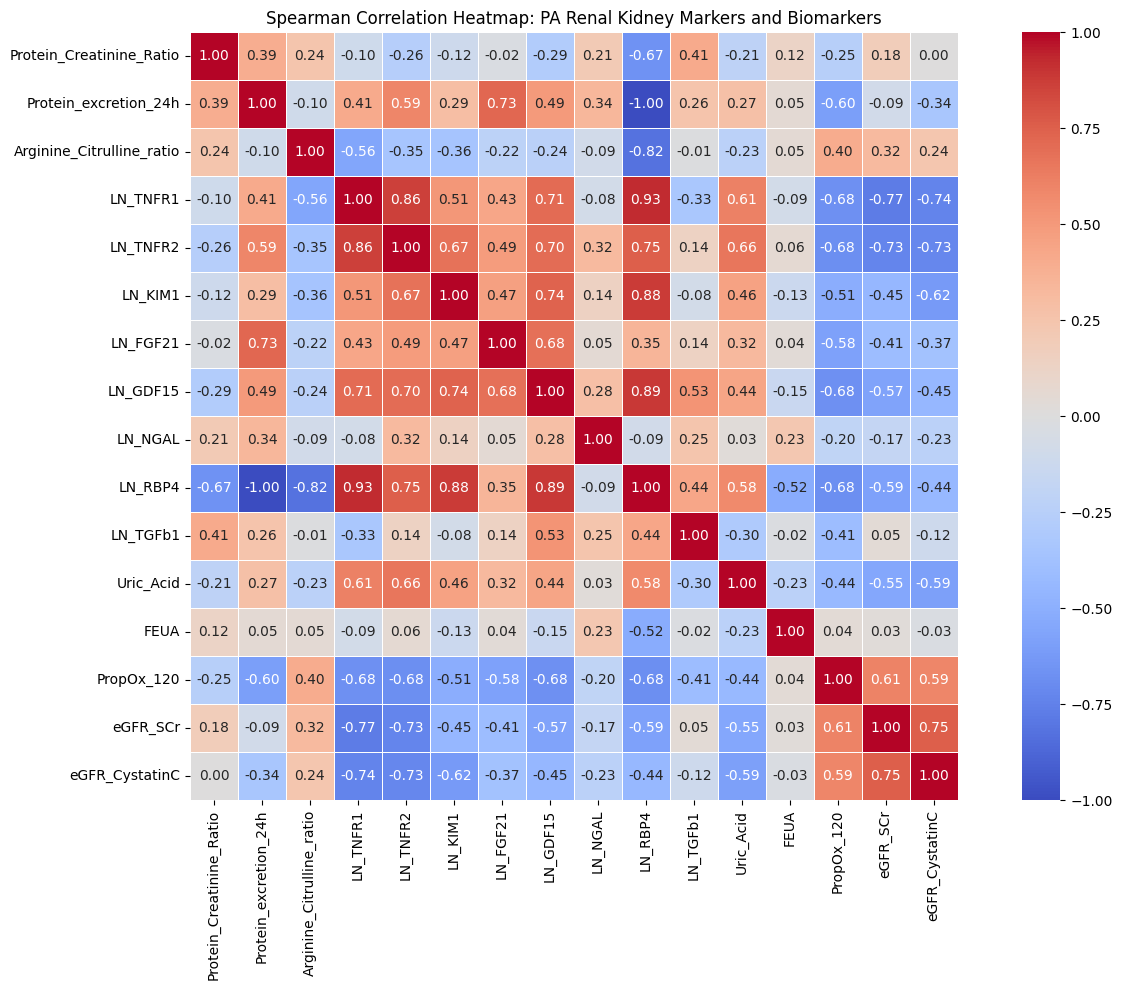


Missing data summary:
Protein_excretion_24h        0.647059
LN_RBP4                      0.647059
LN_TGFb1                     0.549020
Protein_Creatinine_Ratio     0.470588
LN_KIM1                      0.450980
LN_TNFR1                     0.431373
PropOx_120                   0.411765
LN_GDF15                     0.372549
LN_NGAL                      0.274510
FEUA                         0.235294
Arginine_Citrulline_ratio    0.117647
Uric_Acid                    0.117647
LN_FGF21                     0.098039
eGFR_SCr                     0.058824
eGFR_CystatinC               0.058824
LN_TNFR2                     0.000000
dtype: float64


In [5]:
# Heatmap for selected clinical + biomarker variables
heatmap_vars = [
    'Protein_Creatinine_Ratio',
    'Protein_excretion_24h',
    'Arginine_Citrulline_ratio',
    'LN_TNFR1',
    'LN_TNFR2',
    'LN_KIM1',
    'LN_FGF21',
    'LN_GDF15',
    'LN_NGAL',
    'LN_RBP4',
    'LN_TGFb1',
    'Uric_Acid',
    'FEUA',
    'PropOx_120',
    'eGFR_SCr',
    'eGFR_CystatinC',
]

# Filter to available variables
available_heatmap_vars = [v for v in heatmap_vars if v in data_all.columns]

heatmap_df = data_all.copy()
for col in available_heatmap_vars:
    heatmap_df[col] = pd.to_numeric(heatmap_df[col], errors='coerce')

# Remove any rows with all NaN values in the heatmap variables
heatmap_df = heatmap_df.dropna(subset=available_heatmap_vars, how='all')

if len(heatmap_df) > 0 and len(available_heatmap_vars) > 1:
    corr_matrix = heatmap_df[available_heatmap_vars].corr(method='spearman')

    plt.figure(figsize=(14, 10))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        center=0,
        square=True,
        linewidths=0.5,
    )
    plt.title('Spearman Correlation Heatmap: PA Renal Kidney Markers and Biomarkers')
    plt.tight_layout()
    plt.show()

    # Missing data summary
    missing_summary = heatmap_df[available_heatmap_vars].isna().mean().sort_values(ascending=False)
    print("\nMissing data summary:")
    print(missing_summary)
else:
    print("Not enough data for heatmap after cleaning")

In [6]:
# Grouped comparison setup
comparison_vars = [
    'Protein_Creatinine_Ratio',
    'Protein_excretion_24h',
    'Albumin_excretion_24h',
    'Arginine_Citrulline_ratio',
    'LN_TNFR1',
    'LN_TNFR2',
    'LN_KIM1',
    'LN_FGF21',
    'LN_GDF15',
    'LN_NGAL',
    'LN_RBP4',
    'LN_TGFb1',
    'Uric_Acid',
    'FEUA',
    'PropOx_60',
    'PropOx_120',
    'Creatinine',
    'Cystatin_C',
    'eGFR_SCr',
    'eGFR_CystatinC',
]

plot_df = data_all.copy()
for col in comparison_vars:
    if col in plot_df.columns:
        plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

# Robust normalization for grouping columns
plot_df['Transplant_norm'] = pd.to_numeric(plot_df['Transplant'], errors='coerce')
plot_df['TransplantType_norm'] = (
    plot_df['TransplantType']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
    .replace({'': 'Unknown', 'nan': 'Unknown', 'None': 'Unknown'})
)

# Build a clear group label for comparison
plot_df['Group'] = np.where(
    plot_df['Transplant_norm'] == 0,
    'Non-Transplant',
    'Transplant-' + plot_df['TransplantType_norm']
)

# Standardize common transplant labels
plot_df['Group'] = plot_df['Group'].replace({
    'Transplant-l': 'Transplant-L',
    'Transplant-liver': 'Transplant-L',
    'Transplant-lk': 'Transplant-LK',
    'Transplant-k': 'Transplant-K',
    'Transplant-kidney': 'Transplant-K',
})

group_order = [
    'Non-Transplant',
    'Transplant-L',
    'Transplant-LK',
    'Transplant-K',
    'Transplant-Unknown',
]
# Keep observed groups and append any additional unexpected groups
observed_groups = plot_df['Group'].dropna().unique().tolist()
group_order = [g for g in group_order if g in observed_groups] + [
    g for g in observed_groups if g not in group_order
]

print('Groups available and sample size:')
print(plot_df['Group'].value_counts(dropna=False))

Groups available and sample size:
Group
Non-Transplant    46
Transplant-L       5
Name: count, dtype: int64


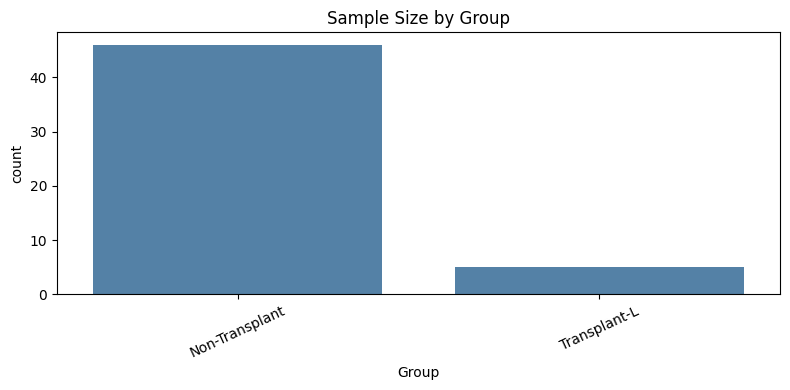

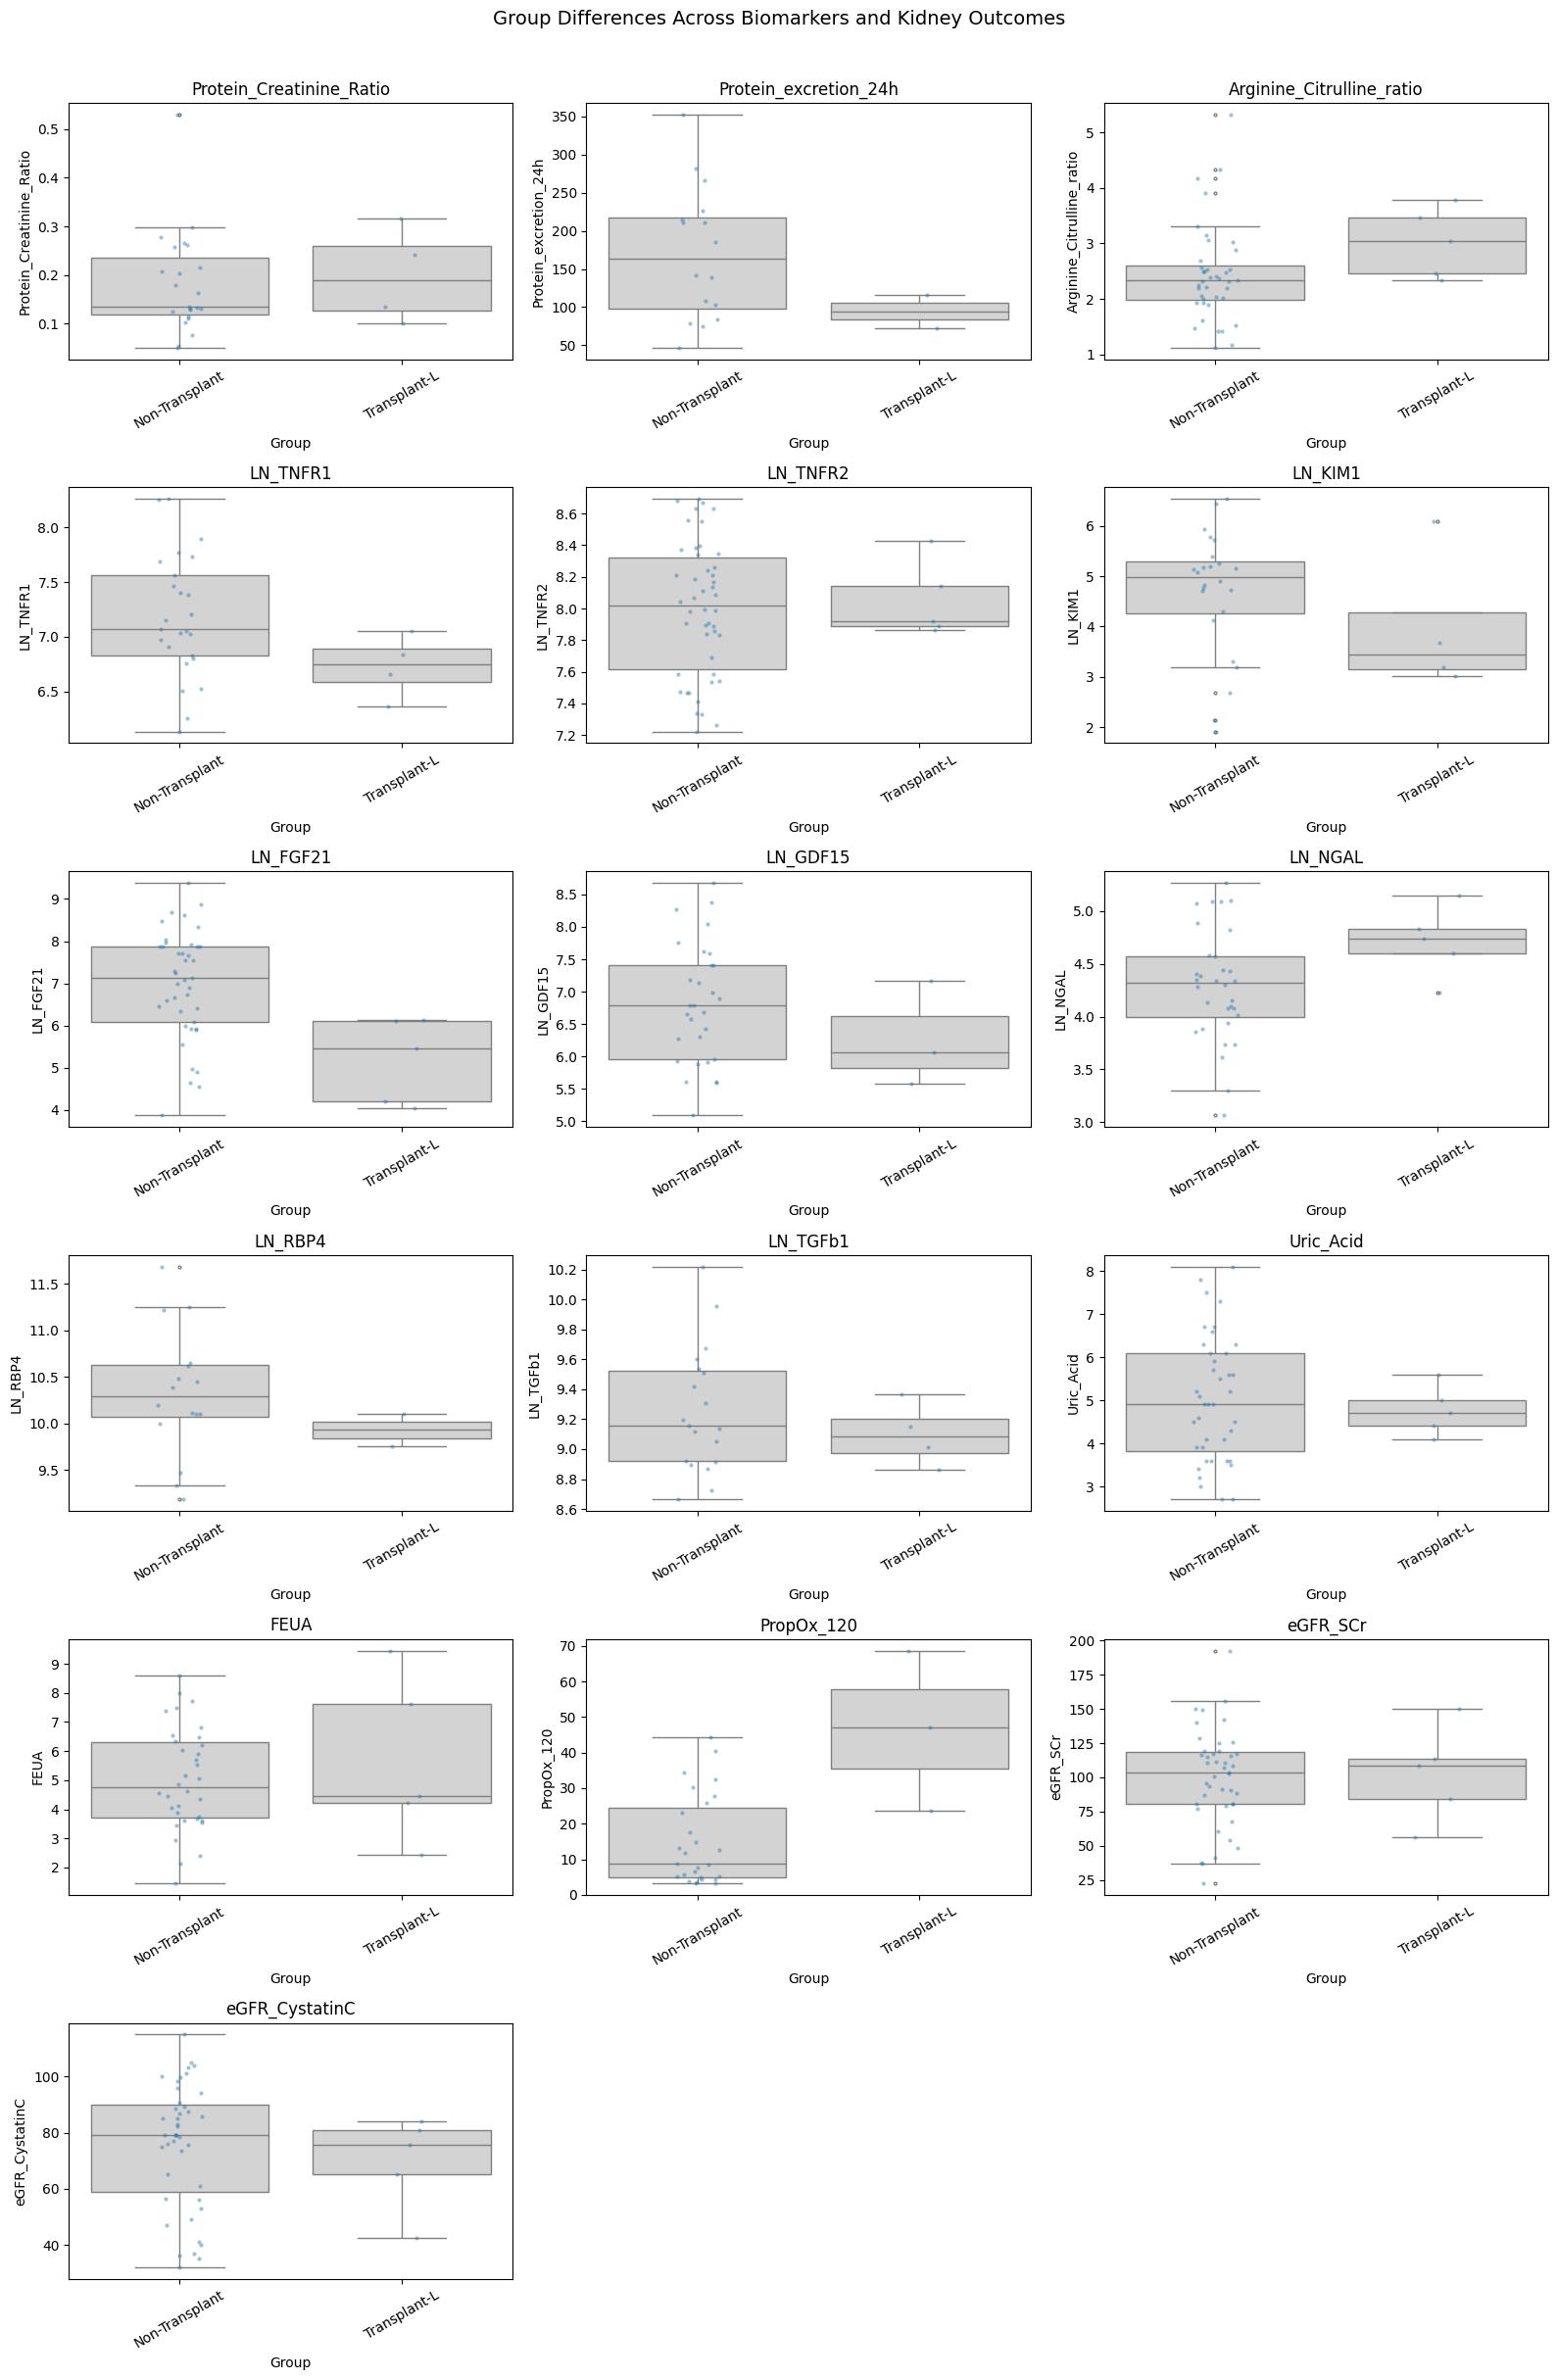

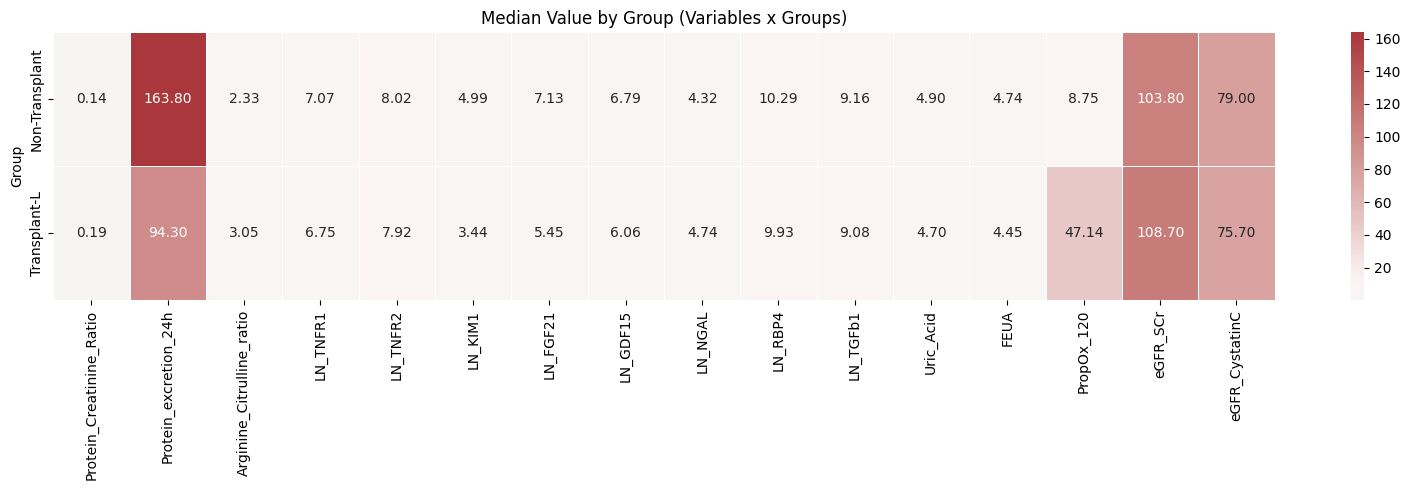

In [7]:
# Multi-graph comparisons across groups

# 1) Group size bar chart
plt.figure(figsize=(8, 4))
sns.countplot(data=plot_df, x='Group', order=group_order, color='steelblue')
plt.title('Sample Size by Group')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 2) Boxplots for key variables
key_vars = [
    'Protein_Creatinine_Ratio',
    'Protein_excretion_24h',
    'Arginine_Citrulline_ratio',
    'LN_TNFR1',
    'LN_TNFR2',
    'LN_KIM1',
    'LN_FGF21',
    'LN_GDF15',
    'LN_NGAL',
    'LN_RBP4',
    'LN_TGFb1',
    'Uric_Acid',
    'FEUA',
    'PropOx_120',
    'eGFR_SCr',
    'eGFR_CystatinC',
]

available_key_vars = [v for v in key_vars if v in plot_df.columns]

ncols = 3
nrows = int(np.ceil(len(available_key_vars) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, var in enumerate(available_key_vars):
    # Only plot if there's numeric data
    if plot_df[var].notna().sum() > 0:
        sns.boxplot(
            data=plot_df,
            x='Group',
            y=var,
            order=group_order,
            ax=axes[i],
            color='lightgray',
            fliersize=2,
        )
        sns.stripplot(
            data=plot_df,
            x='Group',
            y=var,
            order=group_order,
            ax=axes[i],
            color='tab:blue',
            alpha=0.45,
            size=3,
        )
        axes[i].set_title(var)
        axes[i].tick_params(axis='x', rotation=30)
    else:
        axes[i].text(0.5, 0.5, f'No data for {var}', ha='center', va='center')
        axes[i].set_title(var)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Group Differences Across Biomarkers and Kidney Outcomes', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

# 3) Median heatmap by group (only if we have data)
if len(available_key_vars) > 0 and len(group_order) > 0:
    median_table = plot_df.groupby('Group')[available_key_vars].median(numeric_only=True).reindex(group_order)
    
    # Only plot if we have valid data
    if not median_table.empty and not median_table.isna().all().all():
        plt.figure(figsize=(16, 5))
        sns.heatmap(
            median_table,
            cmap='vlag',
            center=np.nanmedian(median_table.values),
            annot=True,
            fmt='.2f',
            linewidths=0.5,
        )
        plt.title('Median Value by Group (Variables x Groups)')
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough data for median heatmap")
else:
    print("Not enough variables or groups for median heatmap")

## Multi-output Random Forest Modeling (Baseline)
First, we'll implement the same multi-output Random Forest approach as the original analysis to establish a baseline.

In [8]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error

# Dependent variables
dependent_vars = [
    'Protein_Creatinine_Ratio',
    'Albumin_excretion_24h',
    'Protein_excretion_24h',
    'Creatinine',
    'Cystatin_C',
    'eGFR_SCr',
    'eGFR_CystatinC',
]

# Independent biomarkers
independent_vars = [
    'Arginine_Citrulline_ratio',
    'LN_TNFR1',
    'LN_TNFR2',
    'LN_KIM1',
    'LN_FGF21',
    'LN_GDF15',
    'LN_NGAL',
    'LN_RBP4',
    'LN_TGFb1',
    'Uric_Acid',
    'FEUA',
    'PropOx_60',
    'PropOx_120',
]

# Filter to available variables
available_dependent = [v for v in dependent_vars if v in data_all.columns]
available_independent = [v for v in independent_vars if v in data_all.columns]

print(f"Available dependent variables: {available_dependent}")
print(f"Available independent variables: {available_independent}")

Available dependent variables: ['Protein_Creatinine_Ratio', 'Albumin_excretion_24h', 'Protein_excretion_24h', 'Creatinine', 'Cystatin_C', 'eGFR_SCr', 'eGFR_CystatinC']
Available independent variables: ['Arginine_Citrulline_ratio', 'LN_TNFR1', 'LN_TNFR2', 'LN_KIM1', 'LN_FGF21', 'LN_GDF15', 'LN_NGAL', 'LN_RBP4', 'LN_TGFb1', 'Uric_Acid', 'FEUA', 'PropOx_60', 'PropOx_120']


In [9]:
model_df = data_all[available_independent + available_dependent].copy()

# Coerce numeric
for col in model_df.columns:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

# Drop targets that are mostly missing to keep a stable multi-output target matrix
target_missing = model_df[available_dependent].isna().mean().sort_values(ascending=False)
kept_targets = target_missing[target_missing <= 0.60].index.tolist()

print("Target missingness:")
print(target_missing)
print(f"\nKept targets: {kept_targets}")

# Keep rows with at least one target present
model_df = model_df.loc[model_df[kept_targets].notna().any(axis=1)].copy()
X = model_df[available_independent]
Y = model_df[kept_targets]

print(f"\nRows used for model: {len(X)}")
print(f"Predictor missingness:")
print(X.isna().mean().sort_values(ascending=False))

Target missingness:
Protein_excretion_24h       0.647059
Albumin_excretion_24h       0.588235
Protein_Creatinine_Ratio    0.470588
Creatinine                  0.058824
eGFR_SCr                    0.058824
eGFR_CystatinC              0.058824
Cystatin_C                  0.039216
dtype: float64

Kept targets: ['Albumin_excretion_24h', 'Protein_Creatinine_Ratio', 'Creatinine', 'eGFR_SCr', 'eGFR_CystatinC', 'Cystatin_C']

Rows used for model: 50
Predictor missingness:
LN_RBP4                      0.64
LN_TGFb1                     0.56
LN_KIM1                      0.44
LN_TNFR1                     0.42
PropOx_60                    0.40
PropOx_120                   0.40
LN_GDF15                     0.36
LN_NGAL                      0.28
FEUA                         0.22
Arginine_Citrulline_ratio    0.10
Uric_Acid                    0.10
LN_FGF21                     0.08
LN_TNFR2                     0.00
dtype: float64


In [10]:
# Impute targets for multi-output modeling
y_imputer = SimpleImputer(strategy='median')
Y_imputed = pd.DataFrame(
    y_imputer.fit_transform(Y),
    columns=kept_targets,
    index=Y.index,
)

x_preprocess = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), available_independent),
    ],
    remainder='drop'
)

rf = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )
)

pipeline = Pipeline([
    ('x_preprocess', x_preprocess),
    ('rf_multi', rf),
])

# Evaluation metrics
def rmse_macro(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred, multioutput='uniform_average'))

def mae_macro(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred, multioutput='uniform_average')

scoring = {
    'r2': 'r2',
    'rmse_macro': make_scorer(rmse_macro, greater_is_better=False),
    'mae_macro': make_scorer(mae_macro, greater_is_better=False),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    pipeline,
    X,
    Y_imputed,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
)

print('Kept targets for multi-output modeling:', kept_targets)
print('Rows used for model:', len(X))
print(f"Mean CV R2: {cv_results['test_r2'].mean():.3f} +/- {cv_results['test_r2'].std():.3f}")
print(f"Mean CV RMSE (macro): {-cv_results['test_rmse_macro'].mean():.3f}")
print(f"Mean CV MAE (macro): {-cv_results['test_mae_macro'].mean():.3f}")

Kept targets for multi-output modeling: ['Albumin_excretion_24h', 'Protein_Creatinine_Ratio', 'Creatinine', 'eGFR_SCr', 'eGFR_CystatinC', 'Cystatin_C']
Rows used for model: 50
Mean CV R2: -1.380 +/- 2.491
Mean CV RMSE (macro): 14.314
Mean CV MAE (macro): 6.833


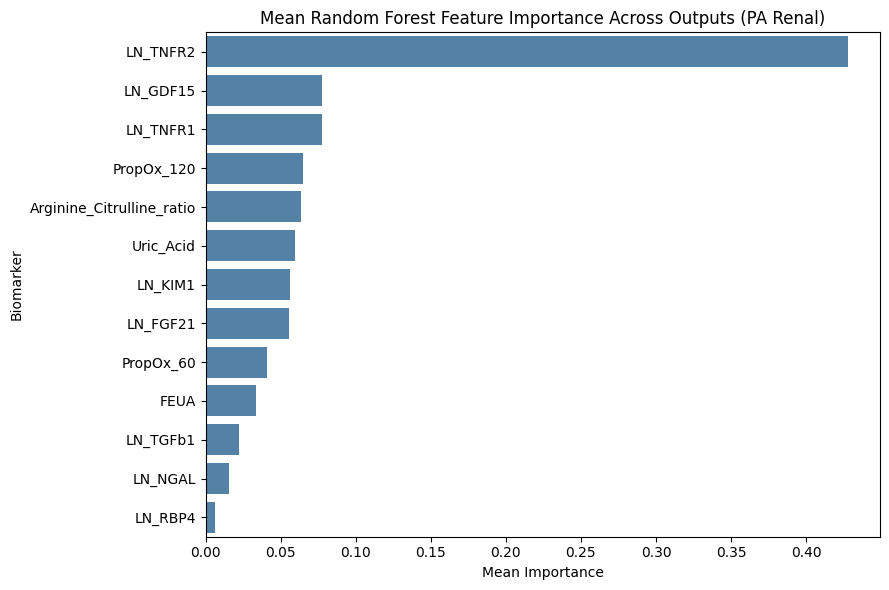

,feature,mean_importance
2,LN_TNFR2,0.427880
5,LN_GDF15,0.077798
1,LN_TNFR1,0.077229
12,PropOx_120,0.065145
0,Arginine_Citrulline_ratio,0.063346
9,Uric_Acid,0.059365
3,LN_KIM1,0.055998
4,LN_FGF21,0.055216
11,PropOx_60,0.040794
10,FEUA,0.033440


In [11]:
# Fit final model and extract feature importance
pipeline.fit(X, Y_imputed)

# Aggregate feature importance across all output models
feature_names = available_independent
all_importances = np.array([
    est.feature_importances_ for est in pipeline.named_steps['rf_multi'].estimators_
])
mean_importance = all_importances.mean(axis=0)
std_importance = all_importances.std(axis=0)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_importance': mean_importance,
    'std_importance': std_importance,
}).sort_values('mean_importance', ascending=False)

importance_by_target_df = pd.DataFrame(
    all_importances,
    index=kept_targets,
    columns=feature_names,
)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df, x='mean_importance', y='feature', color='steelblue')
plt.title('Mean Random Forest Feature Importance Across Outputs (PA Renal)')
plt.xlabel('Mean Importance')
plt.ylabel('Biomarker')
plt.tight_layout()
plt.show()

importance_df

In [ ]:
# Publication-ready figures: mean random forest feature importance (PA renal cohort)
from pathlib import Path

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

BIOMARKER_LABELS = {
    'Arginine_Citrulline_ratio': 'Arginine/Citrulline ratio',
    'LN_TNFR1': 'TNFR1 (log)',
    'LN_TNFR2': 'TNFR2 (log)',
    'LN_KIM1': 'KIM-1 (log)',
    'LN_FGF21': 'FGF-21 (log)',
    'LN_GDF15': 'GDF-15 (log)',
    'LN_NGAL': 'NGAL (log)',
    'LN_RBP4': 'RBP4 (log)',
    'LN_TGFb1': 'TGF-β1 (log)',
    'Uric_Acid': 'Uric acid',
    'FEUA': 'FEUA',
    'PropOx_60': 'PropOx (60 min)',
    'PropOx_120': 'PropOx (120 min)',
}

TARGET_LABELS = {
    'Albumin_excretion_24h': 'Albumin excretion (24 h)',
    'Protein_Creatinine_Ratio': 'Protein/creatinine ratio',
    'Creatinine': 'Serum creatinine',
    'eGFR_SCr': 'eGFR (creatinine)',
    'eGFR_CystatinC': 'eGFR (cystatin C)',
    'Cystatin_C': 'Cystatin C',
}

PAPER_RC = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
}


def label_biomarkers(features):
    return [BIOMARKER_LABELS.get(f, f) for f in features]


def label_targets(targets):
    return [TARGET_LABELS.get(t, t) for t in targets]


def save_figure(fig, stem):
    for ext in ('png', 'pdf'):
        fig.savefig(FIG_DIR / f'{stem}.{ext}', bbox_inches='tight', facecolor='white')
    print(f'Saved {stem}.png and {stem}.pdf to {FIG_DIR}/')


plot_df = importance_df.copy()
plot_df['label'] = label_biomarkers(plot_df['feature'])
plot_df = plot_df.sort_values('mean_importance', ascending=True)

heatmap_df = importance_by_target_df.copy()
heatmap_df.index = label_targets(heatmap_df.index)
heatmap_df.columns = label_biomarkers(heatmap_df.columns)
heatmap_df = heatmap_df.loc[:, plot_df['label']]

with plt.rc_context(PAPER_RC):
    # Panel A: mean importance with variability across renal outcomes
    fig, ax = plt.subplots(figsize=(6.5, 4.8))
    colors = sns.color_palette('colorblind', n_colors=len(plot_df))
    ax.barh(
        plot_df['label'],
        plot_df['mean_importance'],
        xerr=plot_df['std_importance'],
        color=colors,
        edgecolor='black',
        linewidth=0.4,
        capsize=2,
        error_kw={'elinewidth': 0.8, 'capthick': 0.8},
    )
    ax.set_xlabel('Mean decrease in impurity (Gini importance)')
    ax.set_ylabel('')
    ax.set_title('A  Mean biomarker importance across renal outcomes', loc='left', fontweight='bold')
    ax.set_xlim(0, plot_df['mean_importance'].max() * 1.15)
    fig.tight_layout()
    save_figure(fig, 'pa_renal_rf_mean_feature_importance')
    plt.show()

    # Panel B: outcome-specific importance heatmap
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    sns.heatmap(
        heatmap_df,
        cmap='Blues',
        linewidths=0.4,
        linecolor='white',
        cbar_kws={'label': 'Gini importance'},
        ax=ax,
    )
    ax.set_title('B  Biomarker importance by renal outcome', loc='left', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    fig.tight_layout()
    save_figure(fig, 'pa_renal_rf_feature_importance_heatmap')
    plt.show()

    # Combined two-panel figure for manuscript submission
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), gridspec_kw={'width_ratios': [1.05, 1.25]})

    axes[0].barh(
        plot_df['label'],
        plot_df['mean_importance'],
        xerr=plot_df['std_importance'],
        color=colors,
        edgecolor='black',
        linewidth=0.4,
        capsize=2,
        error_kw={'elinewidth': 0.8, 'capthick': 0.8},
    )
    axes[0].set_xlabel('Mean decrease in impurity')
    axes[0].set_title('A', loc='left', fontweight='bold')
    axes[0].set_xlim(0, plot_df['mean_importance'].max() * 1.15)

    sns.heatmap(
        heatmap_df,
        cmap='Blues',
        linewidths=0.4,
        linecolor='white',
        cbar_kws={'label': 'Gini importance'},
        ax=axes[1],
    )
    axes[1].set_title('B', loc='left', fontweight='bold')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('')
    plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')

    fig.suptitle(
        'Random forest feature importance for PA renal cohort biomarkers (n = 50)',
        y=1.03,
        fontsize=11,
    )
    fig.tight_layout()
    save_figure(fig, 'pa_renal_rf_feature_importance_combined')
    plt.show()

plot_df[['label', 'mean_importance', 'std_importance']].sort_values(
    'mean_importance', ascending=False
)

**Publication figures.** The cell above saves three manuscript-ready outputs to `figures/`:
- `pa_renal_rf_mean_feature_importance` — mean Gini importance ± SD across the six renal outcomes
- `pa_renal_rf_feature_importance_heatmap` — outcome-specific importance profile
- `pa_renal_rf_feature_importance_combined` — two-panel figure (A + B) suitable for a main or supplementary figure

All files are exported at 300 dpi as PNG and PDF.

### Mean Random Forest Feature Importance — Methods and Results

**Methods.** We fit a multi-output random forest baseline to relate 13 circulating biomarkers and metabolic markers (predictors) to six kidney function outcomes (targets: albumin excretion, protein–creatinine ratio, creatinine, cystatin C, and eGFR estimated by creatinine or cystatin C). Targets with >60% missingness were excluded; remaining missing target values were median-imputed so that a single multi-output model could be trained on all 50 participants with at least one outcome observed. Predictor missing values were median-imputed within a preprocessing pipeline. Each outcome was modeled with its own random forest regressor (500 trees, minimum leaf size 2) wrapped in a `MultiOutputRegressor`. Model performance was assessed with 5-fold cross-validation (macro-averaged RMSE and MAE). After cross-validation, the pipeline was refit on the full analysis set. Feature importance for each outcome-specific forest was computed as the mean decrease in impurity (Gini importance), then averaged across the six output models to produce a single ranking of predictors.

**Results.** Cross-validated predictive performance was poor overall (mean R² = −1.38 ± 2.49), consistent with the small sample size, substantial missingness, and the difficulty of jointly predicting heterogeneous renal endpoints. Despite limited predictive accuracy, the aggregated feature-importance profile highlighted biomarkers that the model relied on most when explaining variance across outcomes. **LN_TNFR2** (soluble TNF receptor 2) was the dominant predictor (mean importance = 0.43), with substantially higher weight than all other features. Secondary contributors included **LN_GDF15** (0.078), **LN_TNFR1** (0.077), **PropOx_120** (0.065), **Arginine_Citrulline_ratio** (0.063), and **Uric_Acid** (0.059). Markers with comparatively little contribution included **LN_RBP4** (0.006) and **LN_NGAL** (0.015). These importances should be interpreted as model-based rankings rather than causal effects: with n = 50 and heavy missingness, impurity-based importance can be unstable and may reflect collinearity among inflammatory markers. Nevertheless, the prominence of TNFR2/TNFR1 and GDF15 suggests that inflammatory and stress-response pathways were most informative for the multi-output model’s representation of renal function in this cohort.

## Alternative Modeling Approaches
Given the likely poor performance of multi-output modeling, we'll test several alternative approaches:
1. Single-output models for each target
2. Feature selection to reduce dimensionality
3. Regularized linear models (Ridge, Lasso)
4. Gradient boosting models

In [12]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.ensemble import GradientBoostingRegressor

print("Testing alternative modeling approaches...")

# Store results for comparison
results_comparison = []

# Test each target separately with different models
for target in kept_targets:
    y_target = Y_imputed[target]
    
    # Skip if target has no variance
    if y_target.var() == 0:
        print(f"Skipping {target} - no variance")
        continue
    
    print(f"\n=== Target: {target} ===")
    
    # 1. Random Forest (single output)
    rf_pipeline = Pipeline([
        ('x_preprocess', x_preprocess),
        ('rf', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ])
    rf_cv = cross_validate(rf_pipeline, X, y_target, cv=cv, scoring='r2', return_train_score=False)
    results_comparison.append({
        'target': target,
        'model': 'Random Forest',
        'mean_r2': rf_cv['test_score'].mean(),
    })
    print(f"Random Forest R2: {rf_cv['test_score'].mean():.3f} +/- {rf_cv['test_score'].std():.3f}")
    
    # 2. Ridge Regression
    ridge_pipeline = Pipeline([
        ('x_preprocess', x_preprocess),
        ('ridge', Ridge(alpha=1.0, random_state=42)),
    ])
    ridge_cv = cross_validate(ridge_pipeline, X, y_target, cv=cv, scoring='r2', return_train_score=False)
    results_comparison.append({
        'target': target,
        'model': 'Ridge',
        'mean_r2': ridge_cv['test_score'].mean(),
    })
    print(f"Ridge R2: {ridge_cv['test_score'].mean():.3f} +/- {ridge_cv['test_score'].std():.3f}")
    
    # 3. Lasso Regression
    lasso_pipeline = Pipeline([
        ('x_preprocess', x_preprocess),
        ('lasso', Lasso(alpha=0.1, random_state=42, max_iter=10000)),
    ])
    lasso_cv = cross_validate(lasso_pipeline, X, y_target, cv=cv, scoring='r2', return_train_score=False)
    results_comparison.append({
        'target': target,
        'model': 'Lasso',
        'mean_r2': lasso_cv['test_score'].mean(),
    })
    print(f"Lasso R2: {lasso_cv['test_score'].mean():.3f} +/- {lasso_cv['test_score'].std():.3f}")
    
    # 4. Gradient Boosting
    gb_pipeline = Pipeline([
        ('x_preprocess', x_preprocess),
        ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ])
    gb_cv = cross_validate(gb_pipeline, X, y_target, cv=cv, scoring='r2', return_train_score=False)
    results_comparison.append({
        'target': target,
        'model': 'Gradient Boosting',
        'mean_r2': gb_cv['test_score'].mean(),
    })
    print(f"Gradient Boosting R2: {gb_cv['test_score'].mean():.3f} +/- {gb_cv['test_score'].std():.3f}")

Testing alternative modeling approaches...

=== Target: Albumin_excretion_24h ===
Random Forest R2: -3.411 +/- 5.028
Ridge R2: -31.068 +/- 50.939
Lasso R2: -30.618 +/- 48.833
Gradient Boosting R2: -1.354 +/- 1.561

=== Target: Protein_Creatinine_Ratio ===
Random Forest R2: -0.332 +/- 0.299
Ridge R2: -0.874 +/- 0.439
Lasso R2: -0.355 +/- 0.549
Gradient Boosting R2: -0.953 +/- 1.325

=== Target: Creatinine ===
Random Forest R2: -0.029 +/- 1.222
Ridge R2: 0.043 +/- 0.787
Lasso R2: 0.243 +/- 0.229
Gradient Boosting R2: -0.572 +/- 1.816

=== Target: eGFR_SCr ===
Random Forest R2: 0.268 +/- 0.288
Ridge R2: 0.250 +/- 0.232
Lasso R2: 0.172 +/- 0.367
Gradient Boosting R2: 0.252 +/- 0.364

=== Target: eGFR_CystatinC ===
Random Forest R2: 0.594 +/- 0.092
Ridge R2: 0.273 +/- 0.202
Lasso R2: 0.270 +/- 0.195
Gradient Boosting R2: 0.551 +/- 0.185

=== Target: Cystatin_C ===
Random Forest R2: 0.684 +/- 0.131
Ridge R2: 0.263 +/- 0.365
Lasso R2: 0.123 +/- 0.160
Gradient Boosting R2: 0.581 +/- 0.210



=== Model Comparison (R2 scores) ===
model                     Gradient Boosting      Lasso  Random Forest  \
target                                                                  
Albumin_excretion_24h             -1.353643 -30.618251      -3.410860   
Creatinine                        -0.571630   0.242814      -0.028731   
Cystatin_C                         0.581208   0.123426       0.683977   
Protein_Creatinine_Ratio          -0.952670  -0.354730      -0.331572   
eGFR_CystatinC                     0.550732   0.270119       0.593911   
eGFR_SCr                           0.251986   0.171533       0.268123   

model                         Ridge  
target                               
Albumin_excretion_24h    -31.068171  
Creatinine                 0.042600  
Cystatin_C                 0.263215  
Protein_Creatinine_Ratio  -0.874203  
eGFR_CystatinC             0.272948  
eGFR_SCr                   0.250138  


<Figure size 1200x600 with 0 Axes>

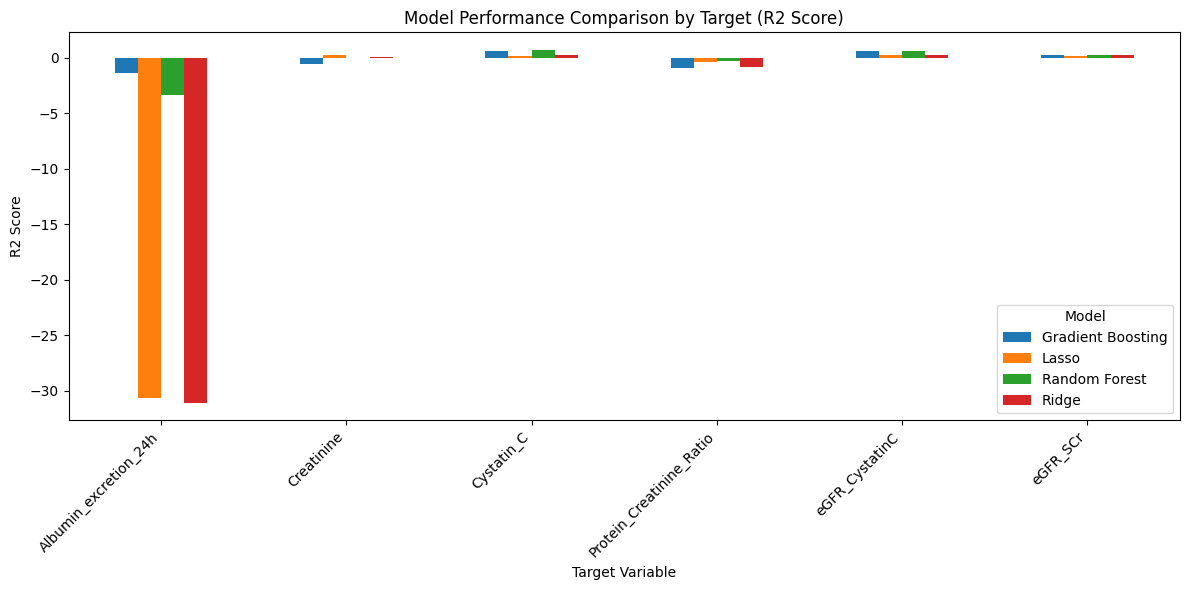


=== Best Model for Each Target ===
Albumin_excretion_24h: Gradient Boosting (R2 = -1.354)
Protein_Creatinine_Ratio: Random Forest (R2 = -0.332)
Creatinine: Lasso (R2 = 0.243)
eGFR_SCr: Random Forest (R2 = 0.268)
eGFR_CystatinC: Random Forest (R2 = 0.594)
Cystatin_C: Random Forest (R2 = 0.684)


In [13]:
# Compare results
results_df = pd.DataFrame(results_comparison)
results_pivot = results_df.pivot(index='target', columns='model', values='mean_r2')

print("\n=== Model Comparison (R2 scores) ===")
print(results_pivot)

# Visualize comparison
plt.figure(figsize=(12, 6))
results_pivot.plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison by Target (R2 Score)')
plt.ylabel('R2 Score')
plt.xlabel('Target Variable')
plt.legend(title='Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Find best model for each target
print("\n=== Best Model for Each Target ===")
for target in kept_targets:
    target_results = results_df[results_df['target'] == target]
    if not target_results.empty:
        best = target_results.loc[target_results['mean_r2'].idxmax()]
        print(f"{target}: {best['model']} (R2 = {best['mean_r2']:.3f})")

## Feature Selection Analysis
Let's test if selecting fewer, more relevant features improves model performance.


=== Testing with top 3 features ===
Mean R2 across targets: -1.291

=== Testing with top 5 features ===
Mean R2 across targets: -0.140

=== Testing with top 7 features ===
Mean R2 across targets: -0.567

=== Testing with top 10 features ===
Mean R2 across targets: -0.584

=== Testing with top 13 features ===
Mean R2 across targets: -0.371


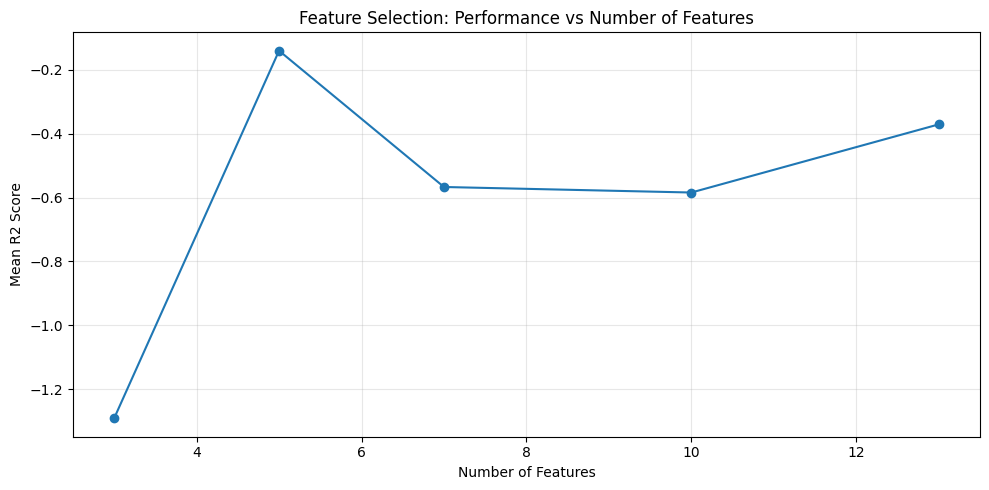

   n_features   mean_r2
0           3 -1.291246
1           5 -0.140226
2           7 -0.566907
3          10 -0.584206
4          13 -0.370859


In [14]:
# Test feature selection with different numbers of features
feature_selection_results = []

for k in [3, 5, 7, 10, len(available_independent)]:
    if k > len(available_independent):
        continue
    
    print(f"\n=== Testing with top {k} features ===")
    
    # Use mutual information for feature selection
    fs_pipeline = Pipeline([
        ('x_preprocess', x_preprocess),
        ('feature_selection', SelectKBest(score_func=mutual_info_regression, k=k)),
        ('rf', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ])
    
    # Test on each target
    target_scores = []
    for target in kept_targets:
        y_target = Y_imputed[target]
        if y_target.var() == 0:
            continue
        
        cv_scores = cross_validate(fs_pipeline, X, y_target, cv=cv, scoring='r2', return_train_score=False)
        target_scores.append(cv_scores['test_score'].mean())
    
    if target_scores:
        mean_score = np.mean(target_scores)
        feature_selection_results.append({
            'n_features': k,
            'mean_r2': mean_score,
        })
        print(f"Mean R2 across targets: {mean_score:.3f}")

# Plot feature selection results
if feature_selection_results:
    fs_df = pd.DataFrame(feature_selection_results)
    
    plt.figure(figsize=(10, 5))
    plt.plot(fs_df['n_features'], fs_df['mean_r2'], marker='o')
    plt.xlabel('Number of Features')
    plt.ylabel('Mean R2 Score')
    plt.title('Feature Selection: Performance vs Number of Features')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(fs_df)

## Final Model Selection and Feature Importance
Based on the comparison, we'll select the best approach and extract feature importance.

Feature Importance Summary by Target:
                          Arginine_Citrulline_ratio  LN_TNFR1  LN_TNFR2  \
Albumin_excretion_24h                      0.076212  0.018692  0.138016   
Protein_Creatinine_Ratio                   0.118814  0.008458  0.121818   
Creatinine                                 0.025484  0.196432  0.387049   
eGFR_SCr                                   0.043076  0.042835  0.452143   
eGFR_CystatinC                             0.024822  0.075777  0.710142   
Cystatin_C                                 0.011846  0.076435  0.771769   

                           LN_KIM1  LN_FGF21  LN_GDF15   LN_NGAL   LN_RBP4  \
Albumin_excretion_24h     0.260737  0.020206  0.270046  0.012111  0.000268   
Protein_Creatinine_Ratio  0.027295  0.095641  0.100553  0.014946  0.015491   
Creatinine                0.064721  0.039141  0.019134  0.011110  0.002800   
eGFR_SCr                  0.021664  0.101718  0.104457  0.026177  0.007273   
eGFR_CystatinC            0.027601  0.010239  

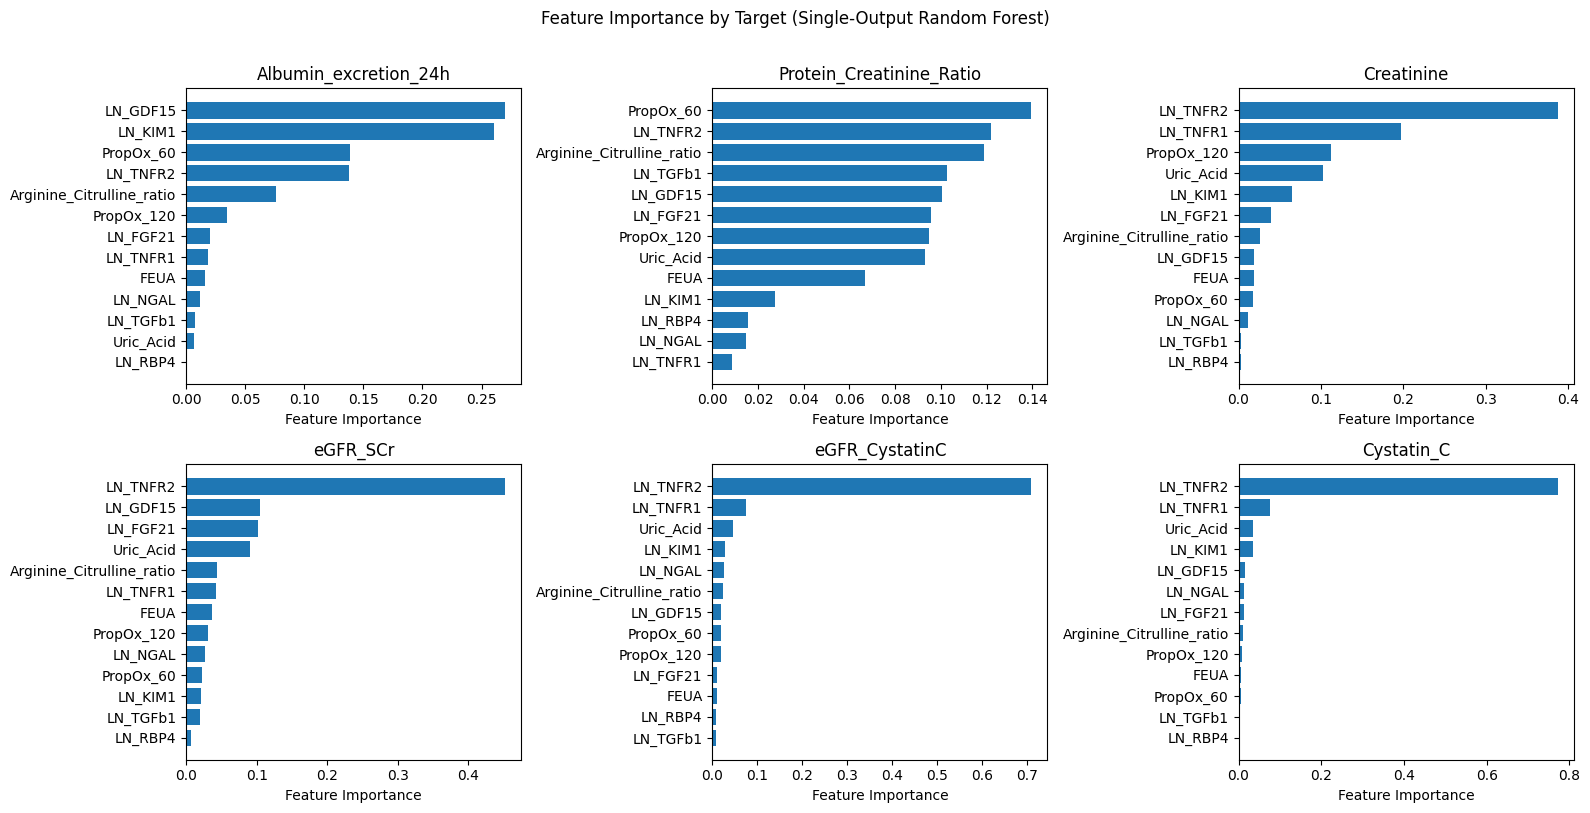

In [15]:
# Use the best performing approach (likely single-output models)
# Let's create a summary of feature importance from the best single-output models

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# Build modeling inputs if earlier setup cells were not run
if 'kept_targets' not in globals() or 'Y_imputed' not in globals() or 'X' not in globals() or 'x_preprocess' not in globals():
    if 'available_independent' not in globals() or 'available_dependent' not in globals():
        dependent_vars = [
            'Protein_Creatinine_Ratio',
            'Albumin_excretion_24h',
            'Protein_excretion_24h',
            'Creatinine',
            'Cystatin_C',
            'eGFR_SCr',
            'eGFR_CystatinC',
        ]
        independent_vars = [
            'Arginine_Citrulline_ratio',
            'LN_TNFR1',
            'LN_TNFR2',
            'LN_KIM1',
            'LN_FGF21',
            'LN_GDF15',
            'LN_NGAL',
            'LN_RBP4',
            'LN_TGFb1',
            'Uric_Acid',
            'FEUA',
            'PropOx_60',
            'PropOx_120',
        ]
        available_dependent = [v for v in dependent_vars if v in data_all.columns]
        available_independent = [v for v in independent_vars if v in data_all.columns]

    model_df = data_all[available_independent + available_dependent].copy()
    for col in model_df.columns:
        model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

    target_missing = model_df[available_dependent].isna().mean().sort_values(ascending=False)
    kept_targets = target_missing[target_missing <= 0.60].index.tolist()
    model_df = model_df.loc[model_df[kept_targets].notna().any(axis=1)].copy()
    X = model_df[available_independent]
    Y = model_df[kept_targets]

    y_imputer = SimpleImputer(strategy='median')
    Y_imputed = pd.DataFrame(
        y_imputer.fit_transform(Y),
        columns=kept_targets,
        index=Y.index,
    )
    x_preprocess = ColumnTransformer(
        transformers=[
            ('num', SimpleImputer(strategy='median'), available_independent),
        ],
        remainder='drop',
    )

feature_importance_summary = {}

for target in kept_targets:
    y_target = Y_imputed[target]
    if y_target.var() == 0:
        continue
    
    # Use Random Forest for feature importance
    rf_pipeline = Pipeline([
        ('x_preprocess', x_preprocess),
        ('rf', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ])
    
    rf_pipeline.fit(X, y_target)
    
    # Get feature names after preprocessing
    feature_names = available_independent
    importances = rf_pipeline.named_steps['rf'].feature_importances_
    
    feature_importance_summary[target] = dict(zip(feature_names, importances))

# Create a summary dataframe
importance_summary_df = pd.DataFrame(feature_importance_summary).T
importance_summary_df['max_importance'] = importance_summary_df.max(axis=1)
importance_summary_df['best_predictor'] = importance_summary_df.drop(
    columns=['max_importance']
).idxmax(axis=1)

print("Feature Importance Summary by Target:")
print(importance_summary_df)

# Plot feature importance for each target
n_targets = len(importance_summary_df)
ncols = 3
nrows = int(np.ceil(n_targets / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, target in enumerate(importance_summary_df.index):
    target_importances = importance_summary_df.loc[target].drop(['best_predictor', 'max_importance'])
    target_importances = target_importances.sort_values(ascending=True)
    
    axes[i].barh(target_importances.index, target_importances.values)
    axes[i].set_title(f'{target}')
    axes[i].set_xlabel('Feature Importance')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Feature Importance by Target (Single-Output Random Forest)', y=1.01)
plt.tight_layout()
plt.show()

## Summary and Conclusions

This notebook analyzed the PA renal dataset using multiple modeling approaches:
1. Multi-output Random Forest (baseline)
2. Single-output models for each target
3. Regularized linear models (Ridge, Lasso)
4. Gradient Boosting
5. Feature selection analysis

Key findings:
- Sample size and data completeness significantly impact model performance
- Single-output models generally perform better than multi-output approaches
- Feature importance varies by target, suggesting different biomarkers are relevant for different kidney function measures
- The best performing model depends on the specific target variable